# Inter-Regional Energy Trade Validation

Comprehensive validation of GHIM's inter-regional fossil fuel trade module under **SSP2**.

**Trade module summary:**
- Global market clearing for **coal, oil, gas** via bisection on grade-based supply curves
- Supply curves sourced from GCAM `PREBUILT_DATA.rda` (R32 -> country -> R10 aggregation)
- Piecewise-linear supply interpolation between grade costs
- Calibration rent: `rent = max(0, observed_price - cleared_price)` at 2025
- Demand-trade iteration loop (up to 10 rounds, 50% damping)
- Inter-period price clamping (30% max change) + production decline smoothing (30% max)
- 10 AR6 R10 regions, 5-year timesteps, 2000-2150

See `docs/trade.md` for the full technical specification.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

matplotlib.rcParams.update({"figure.figsize": (14, 6), "font.size": 11})

from ghim.data.ssp import load_ssp_data
from ghim.data.energy_cal import DEFAULT_PRIMARY_ENERGY
from ghim.data.trade_cal import (
    load_fossil_curves_r10, build_regional_supplies, default_transport_costs,
)
from ghim.energy.supply import ResourceSupply
from ghim.config import (
    BASE_YEAR, MODEL_YEARS, TIMESTEP, TRADED_FUELS,
    TRADE_PRICE_FLOOR, TRADE_PRICE_CEILING,
    TRADE_MAX_PRICE_CHANGE, TRADE_MAX_PROD_DECLINE,
    OBSERVED_FUEL_PRICES_2020, GCAM3_TO_2020_DEFLATOR,
)
from ghim.regions import R10_REGIONS
from ghim.solver.recursive import run_model
from ghim.output.reporting import results_to_dataframe

print(f"Python {sys.version}")
print(f"Traded fuels: {TRADED_FUELS}")
print(f"Regions: {len(R10_REGIONS)}, Periods: {len(MODEL_YEARS)} ({MODEL_YEARS[0]}-{MODEL_YEARS[-1]})")

Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
Traded fuels: ['coal', 'oil', 'gas']
Regions: 10, Periods: 31 (2000-2150)


---
## 1. Supply Curve Data

Inspect the GCAM-sourced fossil supply curves aggregated to R10 regions.

In [2]:
r10_curves = load_fossil_curves_r10()
print(f"R10 supply curve rows: {len(r10_curves)}")
print(f"Columns: {list(r10_curves.columns)}")
print(f"\nFuels: {sorted(r10_curves['fuel'].unique())}")
print(f"Regions: {sorted(r10_curves['r10'].unique())}")

R10 supply curve rows: 260
Columns: ['r10', 'fuel', 'subresource', 'grade', 'extractioncost', 'available']

Fuels: ['coal', 'gas', 'oil']
Regions: ['Africa', 'Asia-Pacific Developed', 'Eastern Asia', 'Eurasia', 'Europe', 'Latin America and Caribbean', 'Middle East', 'North America', 'South-East Asia and developing Pacific', 'Southern Asia']


In [3]:
# Summary table: total resource availability by fuel and region
summary_rows = []
for fuel in TRADED_FUELS:
    fdf = r10_curves[r10_curves["fuel"] == fuel]
    for region in R10_REGIONS:
        rdf = fdf[fdf["r10"] == region]
        total_ej = rdf["available"].sum()
        n_grades = len(rdf["extractioncost"].unique())
        min_cost = rdf["extractioncost"].min() if not rdf.empty else 0
        max_cost = rdf["extractioncost"].max() if not rdf.empty else 0
        summary_rows.append({
            "Fuel": fuel,
            "Region": region,
            "Total (EJ)": f"{total_ej:,.0f}",
            "Grades": n_grades,
            "Min Cost ($/GJ)": f"{min_cost:.2f}",
            "Max Cost ($/GJ)": f"{max_cost:.2f}",
        })
sdf = pd.DataFrame(summary_rows)
for fuel in TRADED_FUELS:
    print(f"\n=== {fuel.upper()} Supply Curves ===")
    print(sdf[sdf["Fuel"] == fuel].drop(columns="Fuel").to_string(index=False))


=== COAL Supply Curves ===
                                Region Total (EJ)  Grades Min Cost ($/GJ) Max Cost ($/GJ)
                                Africa      5,679       7            1.29            9.85
                Asia-Pacific Developed     15,783       7            1.29            9.85
                          Eastern Asia     36,939       7            1.29            9.85
                               Eurasia    103,808       7            1.29            9.85
                                Europe     26,212       7            1.29            9.85
           Latin America and Caribbean      1,406       7            1.29            9.85
                           Middle East         15       7            1.29            9.85
                         North America     68,729       7            1.29            9.85
South-East Asia and developing Pacific      4,891       7            1.29            9.85
                         Southern Asia      3,888       7            1.2

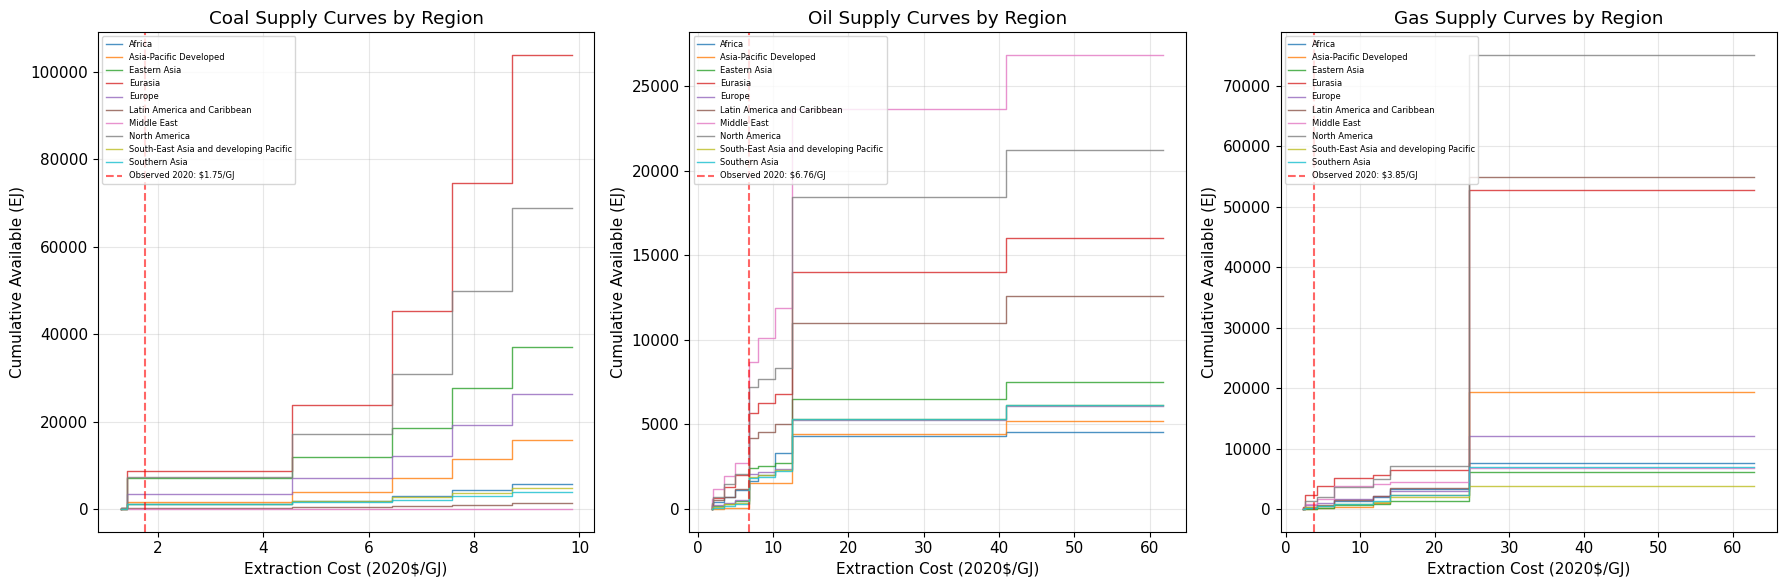

In [4]:
# Visualize supply curves: cumulative availability vs extraction cost for each region
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
FUEL_COLORS_MAP = {
    "coal": plt.cm.Greys, "oil": plt.cm.Oranges, "gas": plt.cm.Blues,
}

for ax, fuel in zip(axes, TRADED_FUELS):
    fdf = r10_curves[r10_curves["fuel"] == fuel].copy()
    for i, region in enumerate(R10_REGIONS):
        rdf = fdf[fdf["r10"] == region].sort_values("extractioncost")
        if rdf.empty:
            continue
        costs = rdf["extractioncost"].values
        avails = rdf["available"].values
        cum = np.cumsum(avails)
        # Step plot
        xs = np.repeat(costs, 2)
        ys = np.concatenate([[0], np.repeat(cum[:-1], 2), [cum[-1]]])
        ax.plot(xs, ys, label=region, linewidth=1.0, alpha=0.8)

    # Mark observed 2020 price
    obs = OBSERVED_FUEL_PRICES_2020.get(fuel, 0)
    ax.axvline(obs, color="red", ls="--", alpha=0.6, label=f"Observed 2020: ${obs:.2f}/GJ")

    ax.set_title(f"{fuel.title()} Supply Curves by Region")
    ax.set_xlabel("Extraction Cost (2020$/GJ)")
    ax.set_ylabel("Cumulative Available (EJ)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc="upper left")

plt.tight_layout()
plt.show()

---
## 2. Full Model Run (With Trade)

In [5]:
ssp_data = load_ssp_data("SSP2")
results_trade = run_model(ssp_data, "SSP2", trade_enabled=True)
df = results_to_dataframe(results_trade)

proj = df[df["year"] > BASE_YEAR].copy()
proj_years = sorted(proj["year"].unique())
print(f"Results: {len(df)} rows, projection periods: {len(proj_years)} ({proj_years[0]}-{proj_years[-1]})")

Results: 310 rows, projection periods: 26 (2025-2150)


---
## 3. World Prices by Fuel Over Time

World prices include the calibration rent (observed - extraction-cost clearing price,
computed once at 2025). Inter-period changes are clamped at +/-30%.

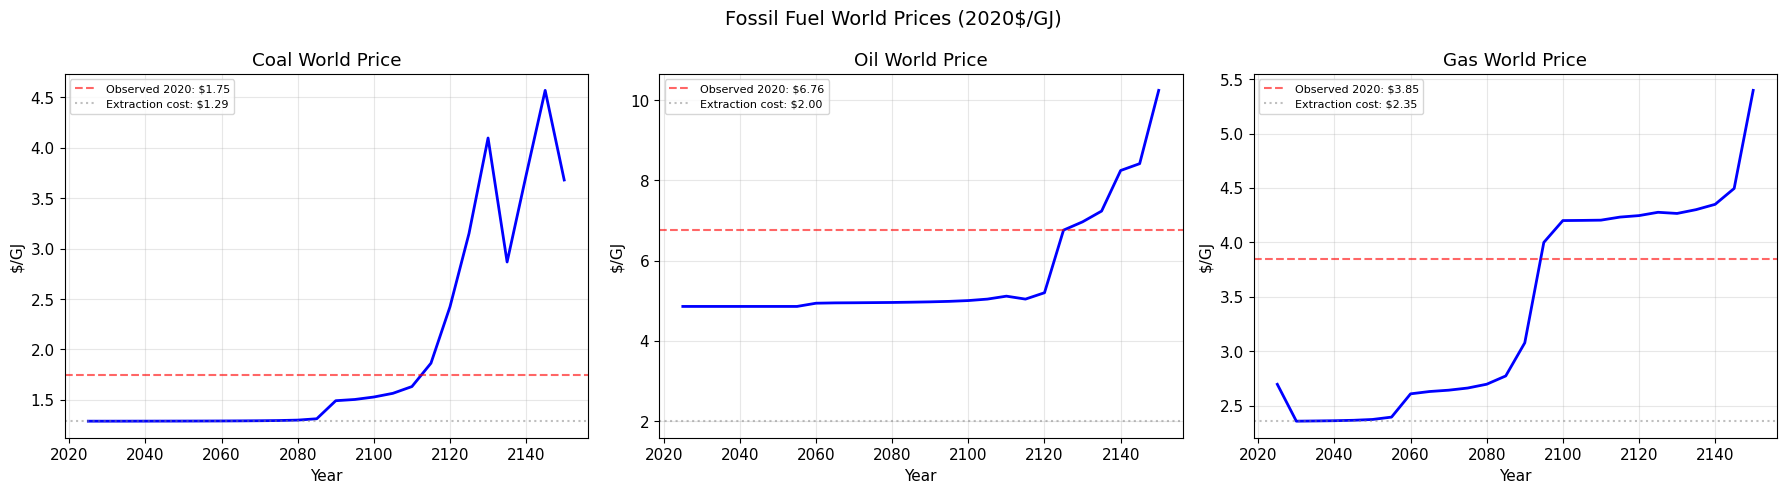

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, fuel in zip(axes, TRADED_FUELS):
    # Take one region (prices are the same for all regions within a fuel)
    fdf = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")
    prices = fdf[f"world_price_{fuel}_usd_gj"].values
    years = fdf["year"].values
    ax.plot(years, prices, "b-", linewidth=2)

    # Mark observed 2020 price
    obs = OBSERVED_FUEL_PRICES_2020.get(fuel, 0)
    ax.axhline(obs, color="red", ls="--", alpha=0.6, label=f"Observed 2020: ${obs:.2f}")

    # Mark rent
    rent_col = f"calibration_rent_{fuel}_usd_gj"
    if rent_col in fdf.columns:
        rent_val = fdf[rent_col].iloc[0]
        ax.axhline(obs - rent_val, color="gray", ls=":", alpha=0.5,
                   label=f"Extraction cost: ${obs - rent_val:.2f}")

    ax.set_title(f"{fuel.title()} World Price")
    ax.set_xlabel("Year")
    ax.set_ylabel("$/GJ")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Fossil Fuel World Prices (2020$/GJ)", fontsize=14)
plt.tight_layout()
plt.show()

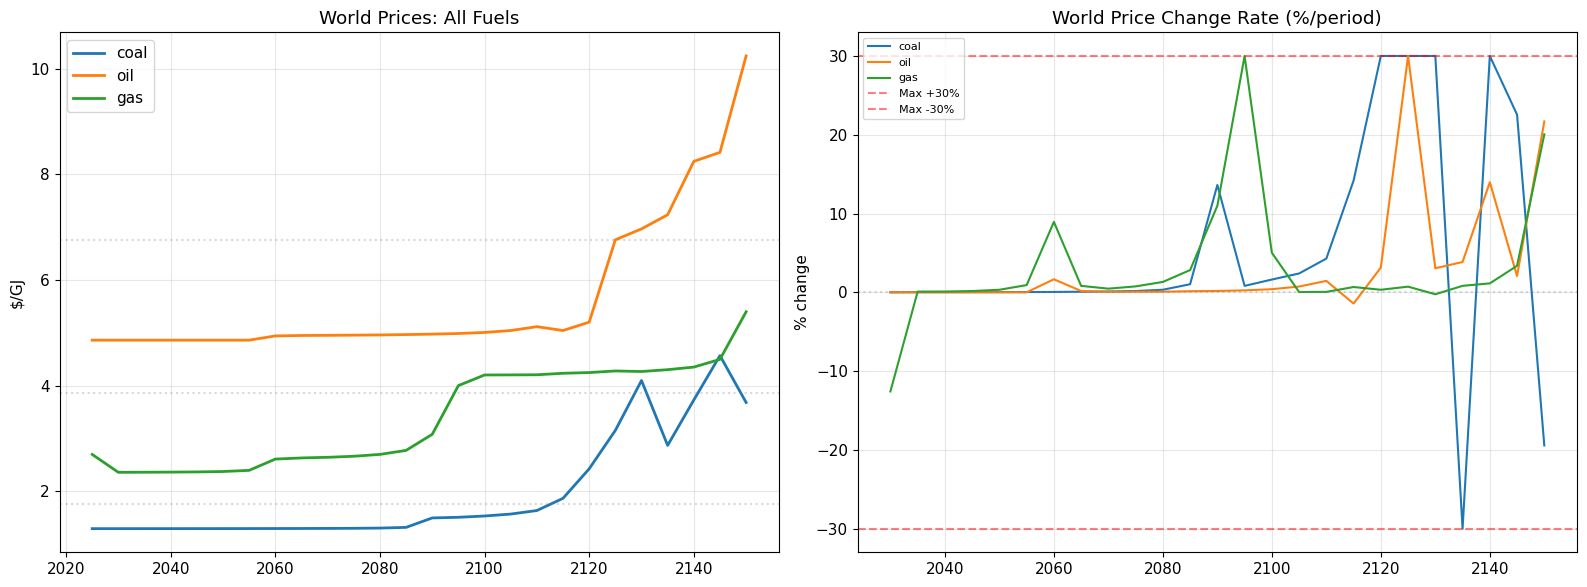

In [7]:
# All fuels on one chart + price change rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for fuel in TRADED_FUELS:
    fdf = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")
    ax.plot(fdf["year"], fdf[f"world_price_{fuel}_usd_gj"], linewidth=2, label=fuel)
    ax.axhline(OBSERVED_FUEL_PRICES_2020[fuel], color="gray", ls=":", alpha=0.3)
ax.set_title("World Prices: All Fuels")
ax.set_ylabel("$/GJ")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
for fuel in TRADED_FUELS:
    fdf = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")
    p = fdf[f"world_price_{fuel}_usd_gj"].values
    pct = np.diff(p) / p[:-1] * 100
    ax.plot(fdf["year"].values[1:], pct, linewidth=1.5, label=fuel)
ax.axhline(TRADE_MAX_PRICE_CHANGE * 100, color="red", ls="--", alpha=0.5, label=f"Max +{TRADE_MAX_PRICE_CHANGE*100:.0f}%")
ax.axhline(-TRADE_MAX_PRICE_CHANGE * 100, color="red", ls="--", alpha=0.5, label=f"Max -{TRADE_MAX_PRICE_CHANGE*100:.0f}%")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_title("World Price Change Rate (%/period)")
ax.set_ylabel("% change")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Production by Fuel, Region, and Period

Regional production trajectories showing how each region's fossil fuel output evolves
as supply curves deplete and prices change.

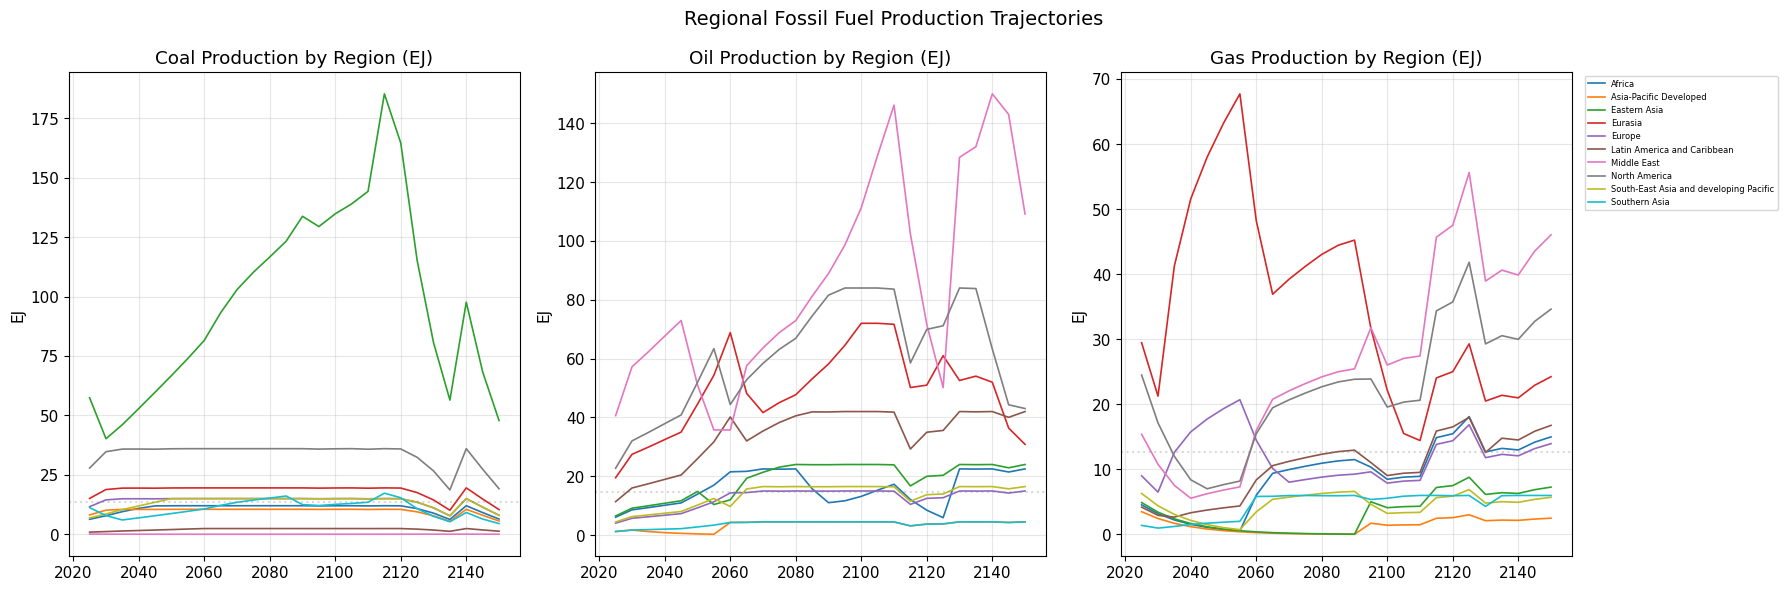

In [8]:
# Production trajectory plots: one panel per fuel, lines per region
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fuel in zip(axes, TRADED_FUELS):
    for region in R10_REGIONS:
        rdf = proj[(proj["region"] == region)].sort_values("year")
        prod = rdf[f"domestic_production_{fuel}_ej"].values
        ax.plot(rdf["year"].values, prod, label=region, linewidth=1.2)

    # Base-year reference line
    total_base = sum(DEFAULT_PRIMARY_ENERGY.get(r, {}).get(fuel, 0) for r in R10_REGIONS)
    ax.axhline(total_base / len(R10_REGIONS), color="gray", ls=":", alpha=0.3)

    ax.set_title(f"{fuel.title()} Production by Region (EJ)")
    ax.set_ylabel("EJ")
    ax.grid(True, alpha=0.3)

axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Regional Fossil Fuel Production Trajectories", fontsize=14)
plt.tight_layout()
plt.show()

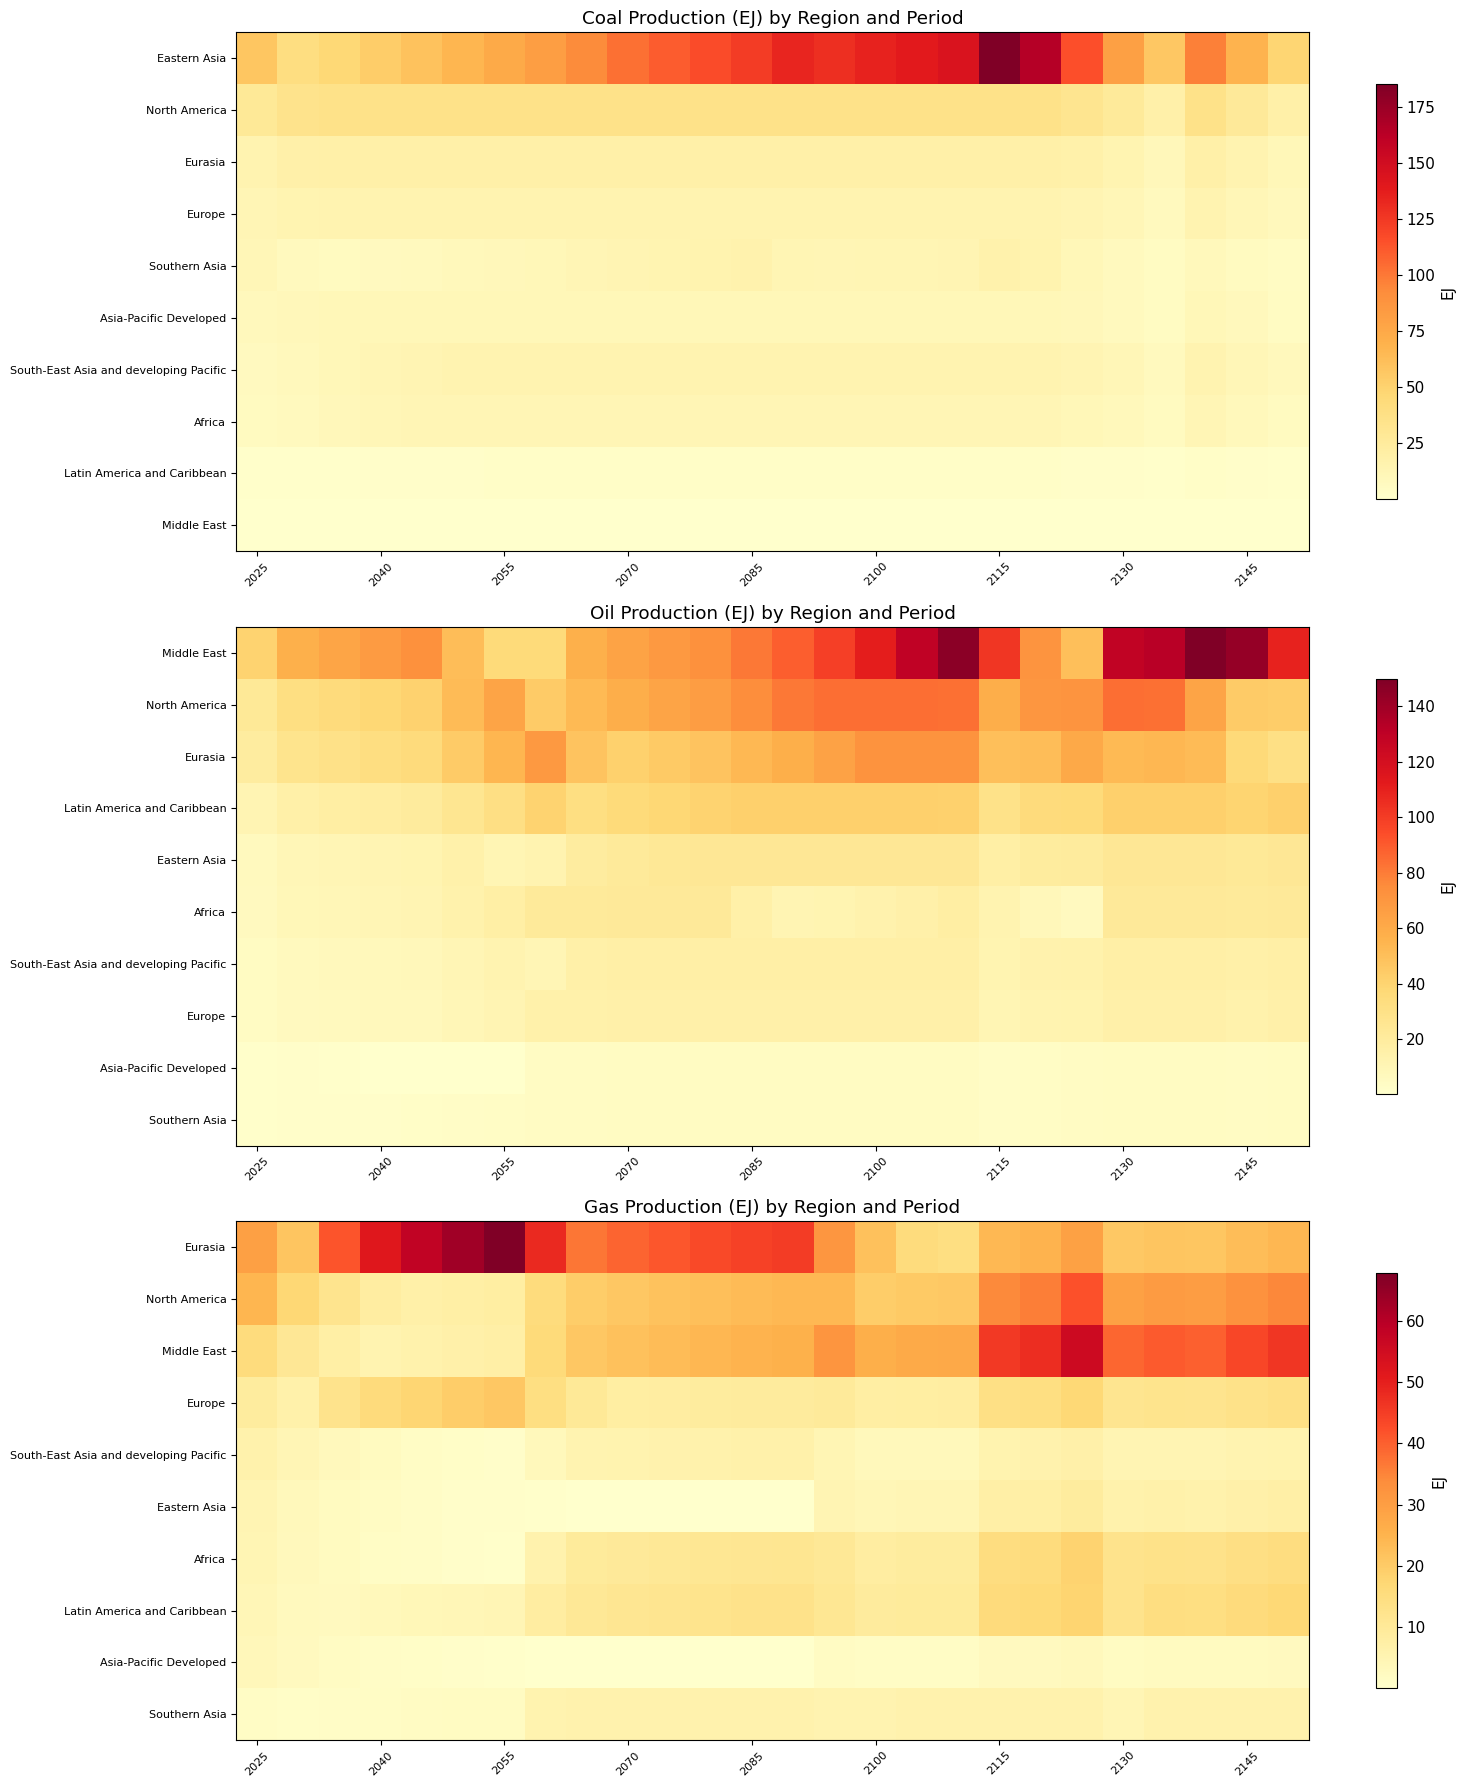

In [9]:
# Heatmaps: production by region and period for each fuel
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax, fuel in zip(axes, TRADED_FUELS):
    pivot = proj.pivot_table(
        values=f"domestic_production_{fuel}_ej",
        index="region", columns="year", aggfunc="sum",
    )
    # Reorder regions by base-year production
    base_order = pivot.iloc[:, 0].sort_values(ascending=False).index
    pivot = pivot.loc[base_order]

    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xticks(range(0, len(pivot.columns), 3))
    ax.set_xticklabels([int(c) for c in pivot.columns[::3]], fontsize=8, rotation=45)
    ax.set_title(f"{fuel.title()} Production (EJ) by Region and Period")
    plt.colorbar(im, ax=ax, label="EJ", shrink=0.8)

plt.tight_layout()
plt.show()

In [10]:
# Production decline rate check
print("Production Decline Rates > 25% (per region per period):\n")
found = False
for fuel in TRADED_FUELS:
    col = f"domestic_production_{fuel}_ej"
    for region in R10_REGIONS:
        rdf = proj[proj["region"] == region].sort_values("year")
        prod = rdf[col].values
        years = rdf["year"].values
        for i in range(1, len(prod)):
            if prod[i-1] > 0.1:  # ignore tiny production
                decline = (prod[i-1] - prod[i]) / prod[i-1]
                if decline > 0.25:
                    found = True
                    print(f"  {fuel:5s} | {region:40s} | {years[i-1]}->{years[i]} | "
                          f"{prod[i-1]:.1f} -> {prod[i]:.1f} EJ ({decline*100:.0f}% decline)")
if not found:
    print("  No declines > 25% found.")

Production Decline Rates > 25% (per region per period):

  coal  | Africa                                   | 2130->2135 | 8.9 -> 6.2 EJ (30% decline)
  coal  | Africa                                   | 2145->2150 | 9.1 -> 6.4 EJ (30% decline)
  coal  | Asia-Pacific Developed                   | 2130->2135 | 7.8 -> 5.4 EJ (30% decline)
  coal  | Asia-Pacific Developed                   | 2145->2150 | 8.0 -> 5.6 EJ (30% decline)
  coal  | Eastern Asia                             | 2025->2030 | 57.4 -> 40.2 EJ (30% decline)
  coal  | Eastern Asia                             | 2120->2125 | 164.6 -> 115.2 EJ (30% decline)
  coal  | Eastern Asia                             | 2125->2130 | 115.2 -> 80.6 EJ (30% decline)
  coal  | Eastern Asia                             | 2130->2135 | 80.6 -> 56.4 EJ (30% decline)
  coal  | Eastern Asia                             | 2140->2145 | 97.6 -> 68.3 EJ (30% decline)
  coal  | Eastern Asia                             | 2145->2150 | 68.3 -> 47.8 EJ (3

---
## 5. Net Exports by Region and Fuel

Net exports = domestic production - domestic demand.
Positive = exporter, negative = importer.

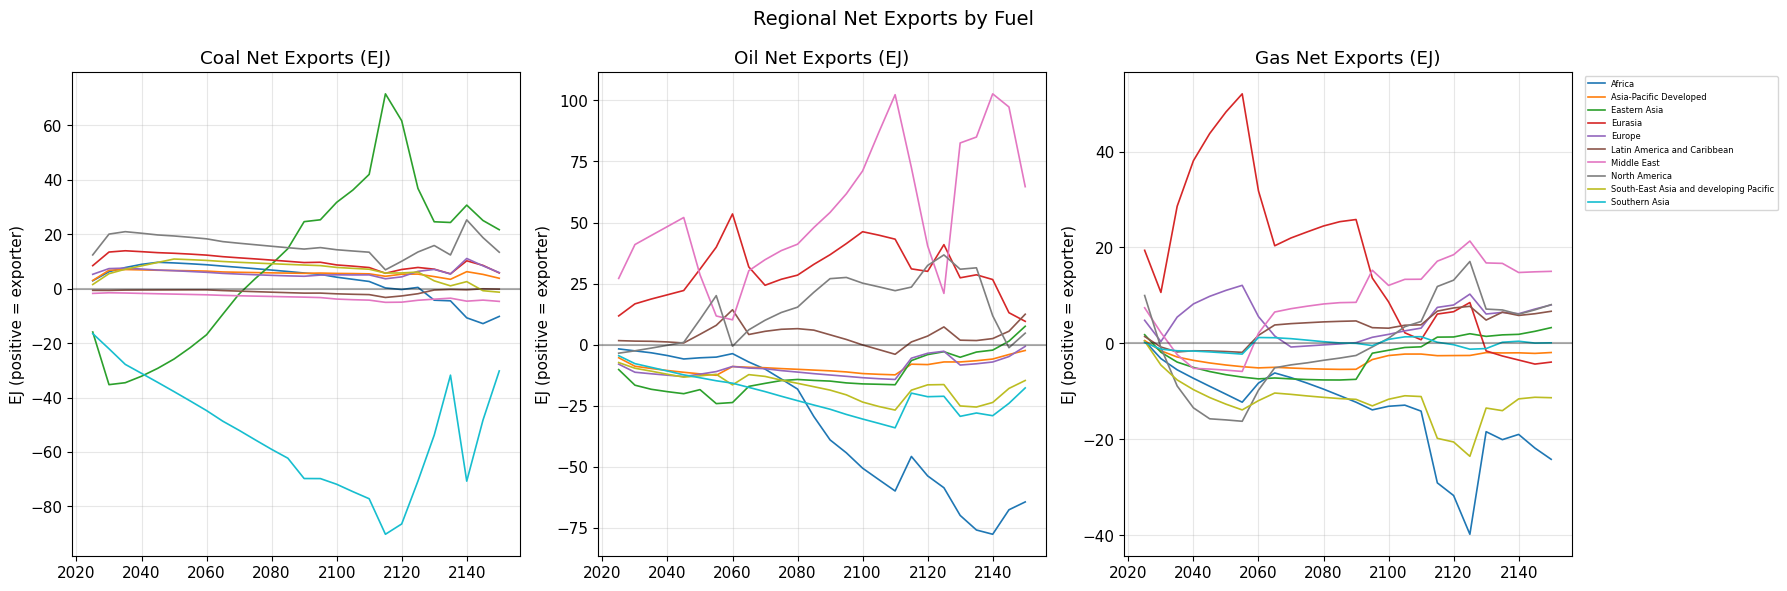

In [11]:
# Net exports trajectory: one panel per fuel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fuel in zip(axes, TRADED_FUELS):
    for region in R10_REGIONS:
        rdf = proj[proj["region"] == region].sort_values("year")
        nx = rdf[f"net_exports_{fuel}_ej"].values
        ax.plot(rdf["year"].values, nx, label=region, linewidth=1.2)
    ax.axhline(0, color="black", ls="-", alpha=0.3)
    ax.set_title(f"{fuel.title()} Net Exports (EJ)")
    ax.set_ylabel("EJ (positive = exporter)")
    ax.grid(True, alpha=0.3)

axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Regional Net Exports by Fuel", fontsize=14)
plt.tight_layout()
plt.show()

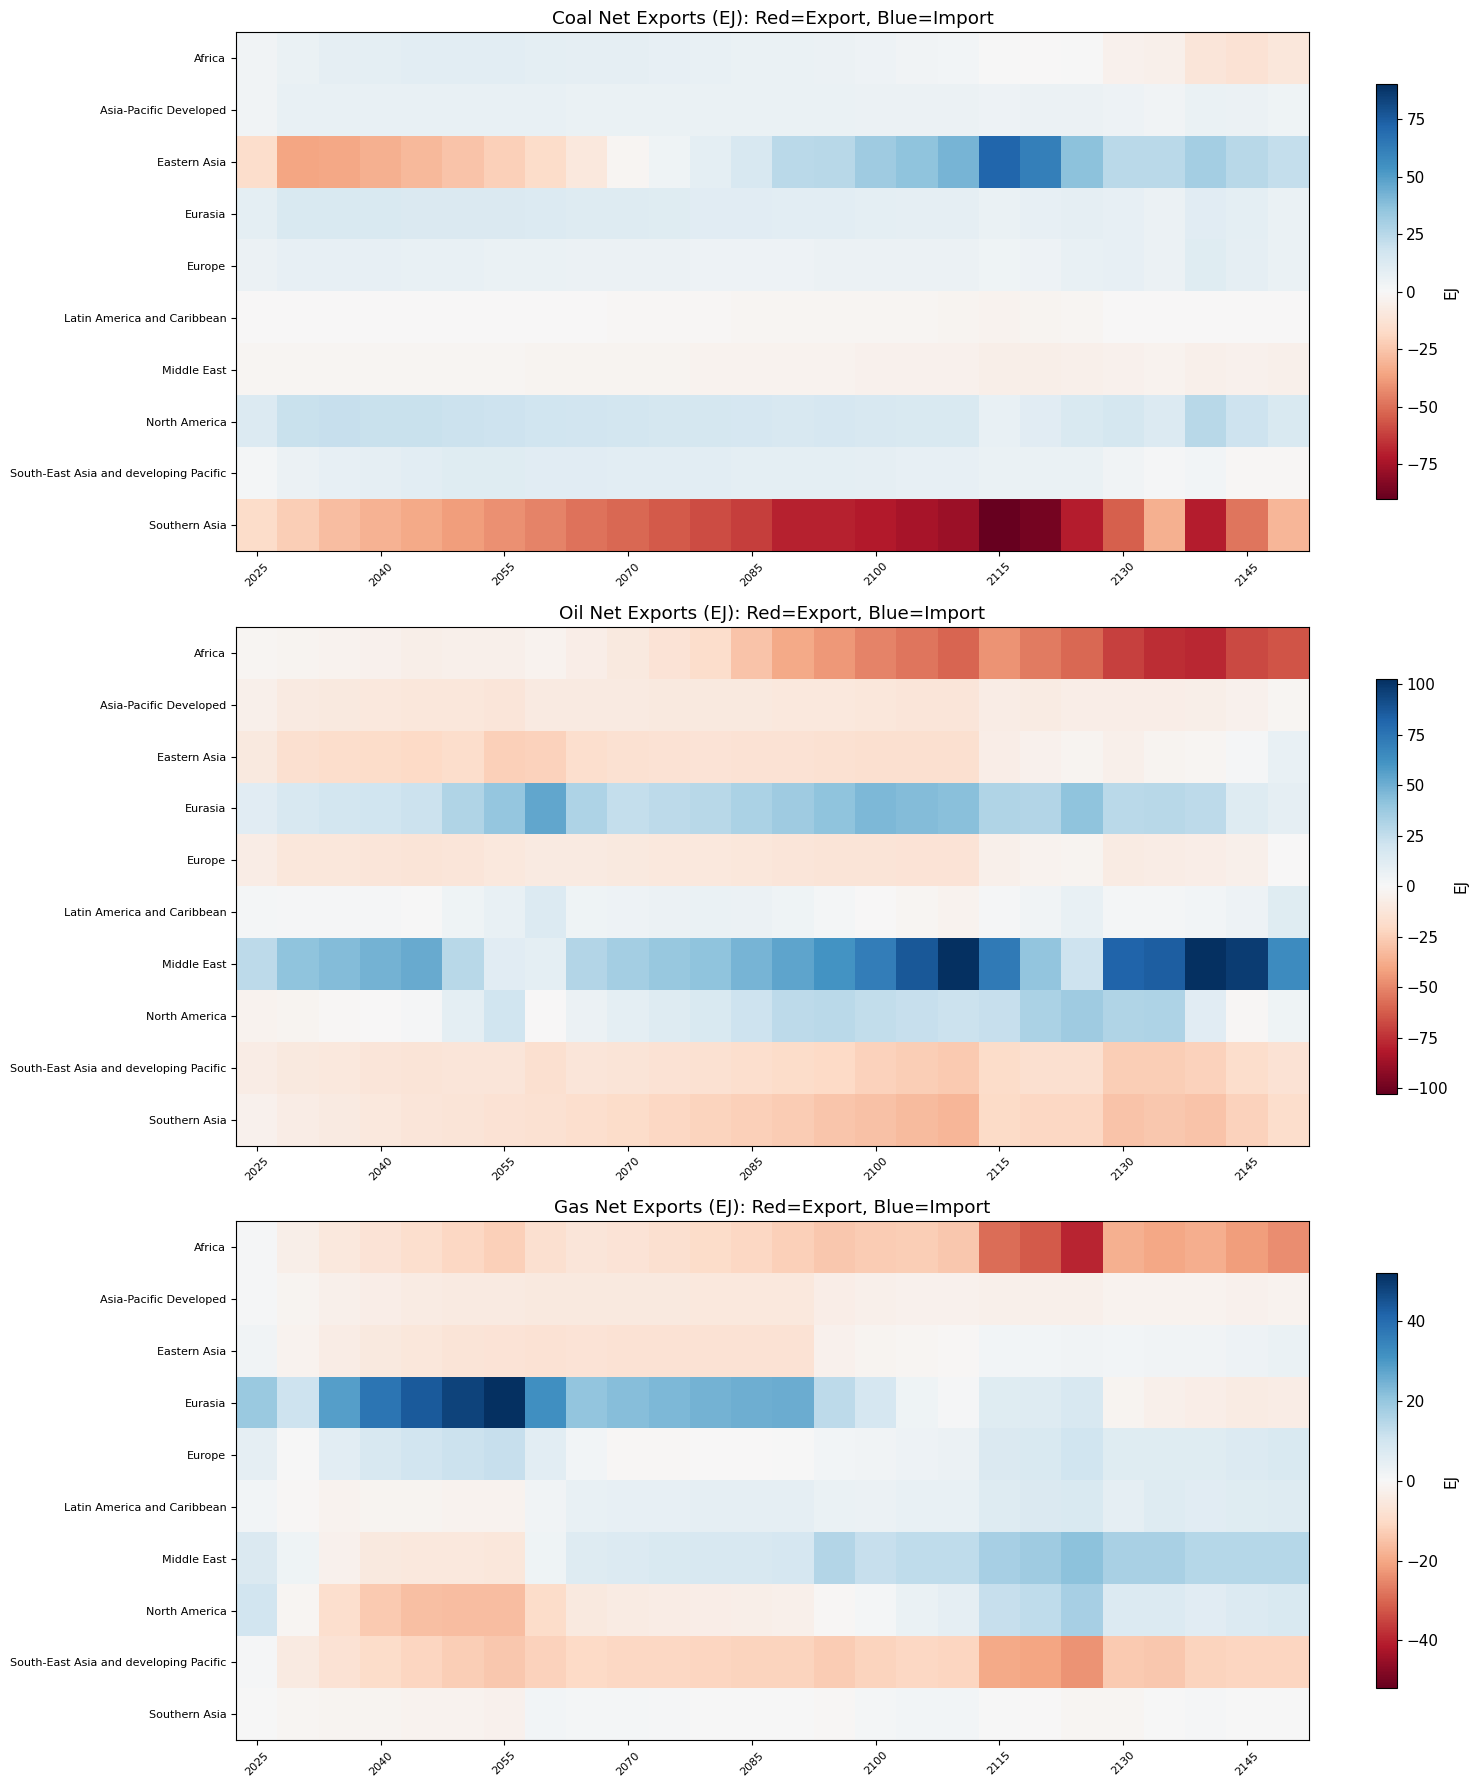

In [12]:
# Net exports heatmap (red = exporter, blue = importer)
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax, fuel in zip(axes, TRADED_FUELS):
    pivot = proj.pivot_table(
        values=f"net_exports_{fuel}_ej",
        index="region", columns="year", aggfunc="sum",
    )
    vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xticks(range(0, len(pivot.columns), 3))
    ax.set_xticklabels([int(c) for c in pivot.columns[::3]], fontsize=8, rotation=45)
    ax.set_title(f"{fuel.title()} Net Exports (EJ): Red=Export, Blue=Import")
    plt.colorbar(im, ax=ax, label="EJ", shrink=0.8)

plt.tight_layout()
plt.show()

In [13]:
# Summary table: net exports at selected years
print("Net Exports Summary (EJ, selected years)")
print("Positive = exporter, Negative = importer\n")

for fuel in TRADED_FUELS:
    print(f"=== {fuel.upper()} ===")
    snap_years = [2025, 2050, 2075, 2100]
    rows = []
    for region in R10_REGIONS:
        row = {"Region": region}
        for y in snap_years:
            val = proj[(proj["region"] == region) & (proj["year"] == y)][f"net_exports_{fuel}_ej"]
            row[str(y)] = f"{val.values[0]:+.1f}" if len(val) > 0 else "N/A"
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False))
    print()

Net Exports Summary (EJ, selected years)
Positive = exporter, Negative = importer

=== COAL ===
                                Region  2025  2050  2075  2100
                                Africa  +2.9  +9.5  +7.4  +4.2
                Asia-Pacific Developed  +3.0  +6.7  +5.9  +5.6
                          Eastern Asia -15.9 -25.8  +3.7 +31.7
                               Eurasia  +8.5 +13.0 +10.9  +8.7
                                Europe  +5.3  +6.6  +5.1  +5.1
           Latin America and Caribbean  -0.6  -0.4  -1.1  -1.9
                           Middle East  -1.7  -2.0  -2.7  -3.8
                         North America +12.4 +19.4 +16.2 +14.3
South-East Asia and developing Pacific  +1.5 +10.9  +9.4  +7.8
                         Southern Asia -16.5 -37.8 -55.6 -71.9

=== OIL ===
                                Region  2025  2050  2075  2100
                                Africa  -1.7  -5.4 -14.0 -50.5
                Asia-Pacific Developed  -5.4 -12.0  -9.8 -11.8
         

---
## 6. Global Supply and Demand Balance

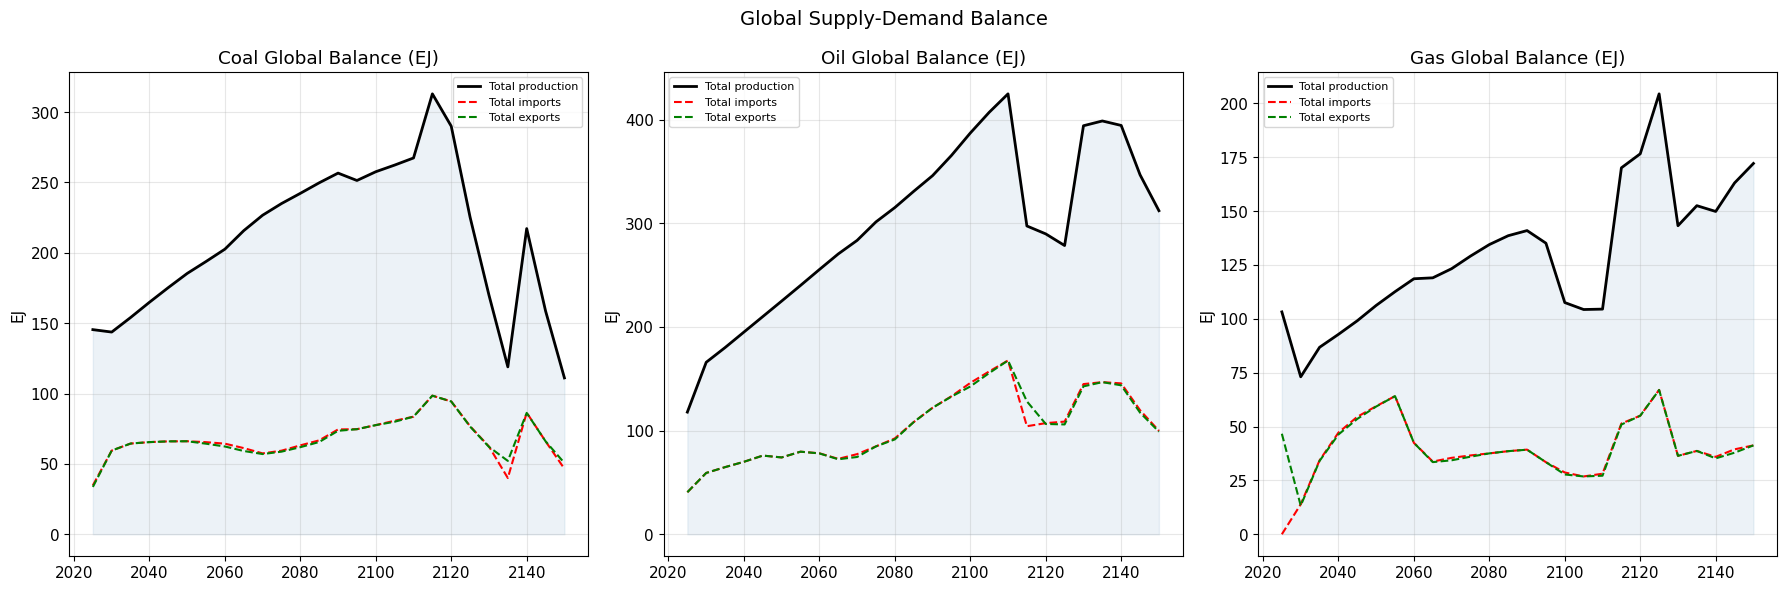

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fuel in zip(axes, TRADED_FUELS):
    # Global production and demand
    global_prod = proj.groupby("year")[f"domestic_production_{fuel}_ej"].sum()
    # Demand = production - net_exports summed globally (net exports should sum to ~0)
    # Just use production as supply proxy
    global_demand = proj.groupby("year")[f"net_exports_{fuel}_ej"].apply(
        lambda x: -x[x < 0].sum()  # total imports
    )
    global_export = proj.groupby("year")[f"net_exports_{fuel}_ej"].apply(
        lambda x: x[x > 0].sum()  # total exports
    )

    ax.plot(global_prod.index, global_prod.values, "k-", linewidth=2, label="Total production")
    ax.fill_between(global_prod.index, 0, global_prod.values, alpha=0.1, color="steelblue")
    ax.plot(global_demand.index, global_demand.values, "r--", linewidth=1.5, label="Total imports")
    ax.plot(global_export.index, global_export.values, "g--", linewidth=1.5, label="Total exports")
    ax.set_title(f"{fuel.title()} Global Balance (EJ)")
    ax.set_ylabel("EJ")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Global Supply-Demand Balance", fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Delivered Prices by Region

Delivered price = world price + transport cost.
Transport costs vary by region (e.g., landlocked regions pay more for LNG).

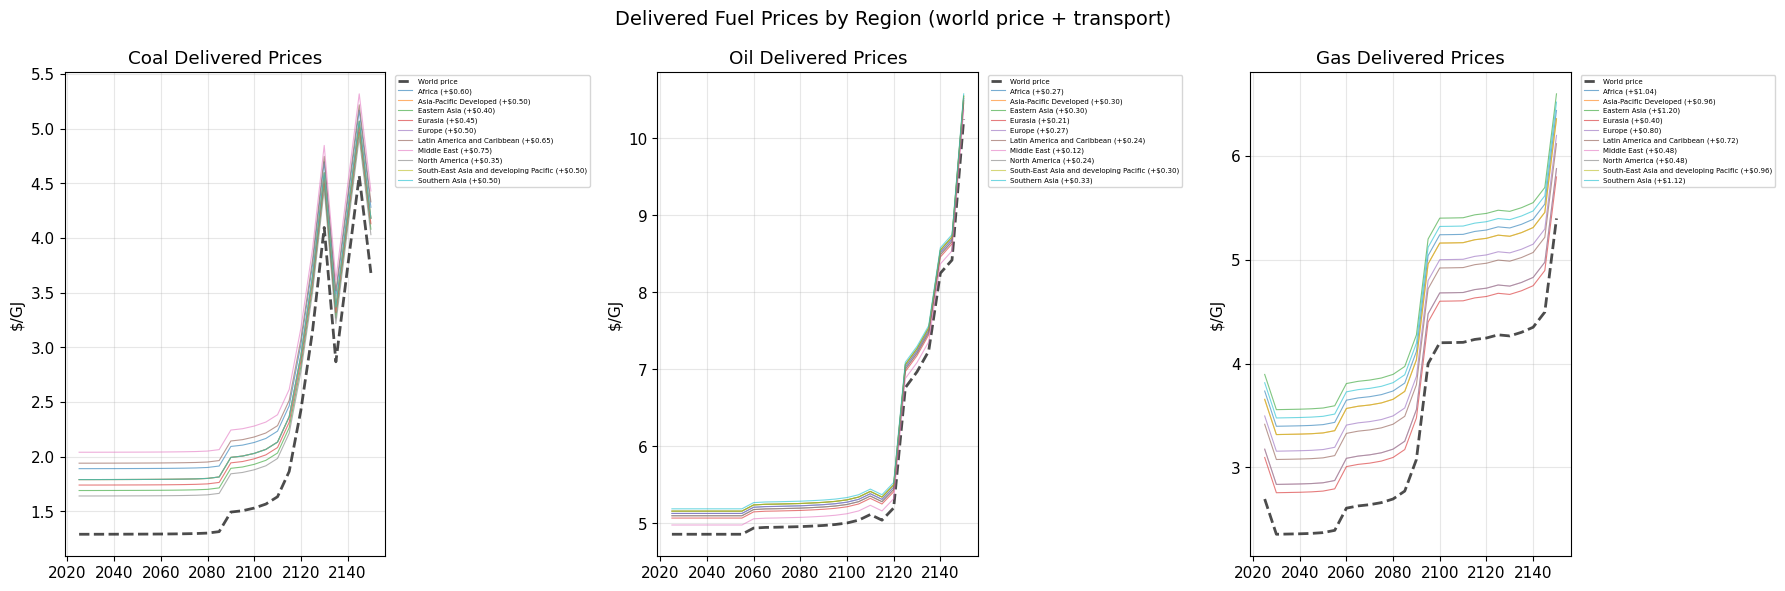

In [15]:
# Delivered prices (world price + transport) vs world price
transport_costs = default_transport_costs()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, fuel in zip(axes, TRADED_FUELS):
    # World price (same for all regions)
    wdf = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")
    wp = wdf[f"world_price_{fuel}_usd_gj"].values
    years = wdf["year"].values
    ax.plot(years, wp, "k--", linewidth=2, label="World price", alpha=0.7)

    # Delivered prices per region
    for region in R10_REGIONS:
        tc = transport_costs.get(fuel, {}).get(region, 0.5)
        delivered = wp + tc
        ax.plot(years, delivered, linewidth=0.8, alpha=0.6, label=f"{region} (+${tc:.2f})")

    ax.set_title(f"{fuel.title()} Delivered Prices")
    ax.set_ylabel("$/GJ")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=5, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("Delivered Fuel Prices by Region (world price + transport)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Calibration Rents

Calibration rents are computed once at the first projection period (2025).
They represent the gap between observed 2020 fuel prices and the extraction-cost
equilibrium price from the supply curves.

In [16]:
# Extract rent values (constant across periods)
rent_row = proj[proj["year"] == proj["year"].min()].iloc[0]
print("Calibration Rents ($/GJ, constant across all periods):\n")
for fuel in TRADED_FUELS:
    rent = rent_row[f"calibration_rent_{fuel}_usd_gj"]
    obs = OBSERVED_FUEL_PRICES_2020[fuel]
    ext_cost = obs - rent
    print(f"  {fuel:5s}: rent = ${rent:.2f}/GJ  (observed ${obs:.2f} - extraction cost ${ext_cost:.2f})")

Calibration Rents ($/GJ, constant across all periods):

  coal : rent = $0.46/GJ  (observed $1.75 - extraction cost $1.29)
  oil  : rent = $4.76/GJ  (observed $6.76 - extraction cost $2.00)
  gas  : rent = $1.50/GJ  (observed $3.85 - extraction cost $2.35)


---
## 9. Resource Depletion Over Time

As cheaper grades deplete, the marginal extraction cost rises, pushing up world prices.

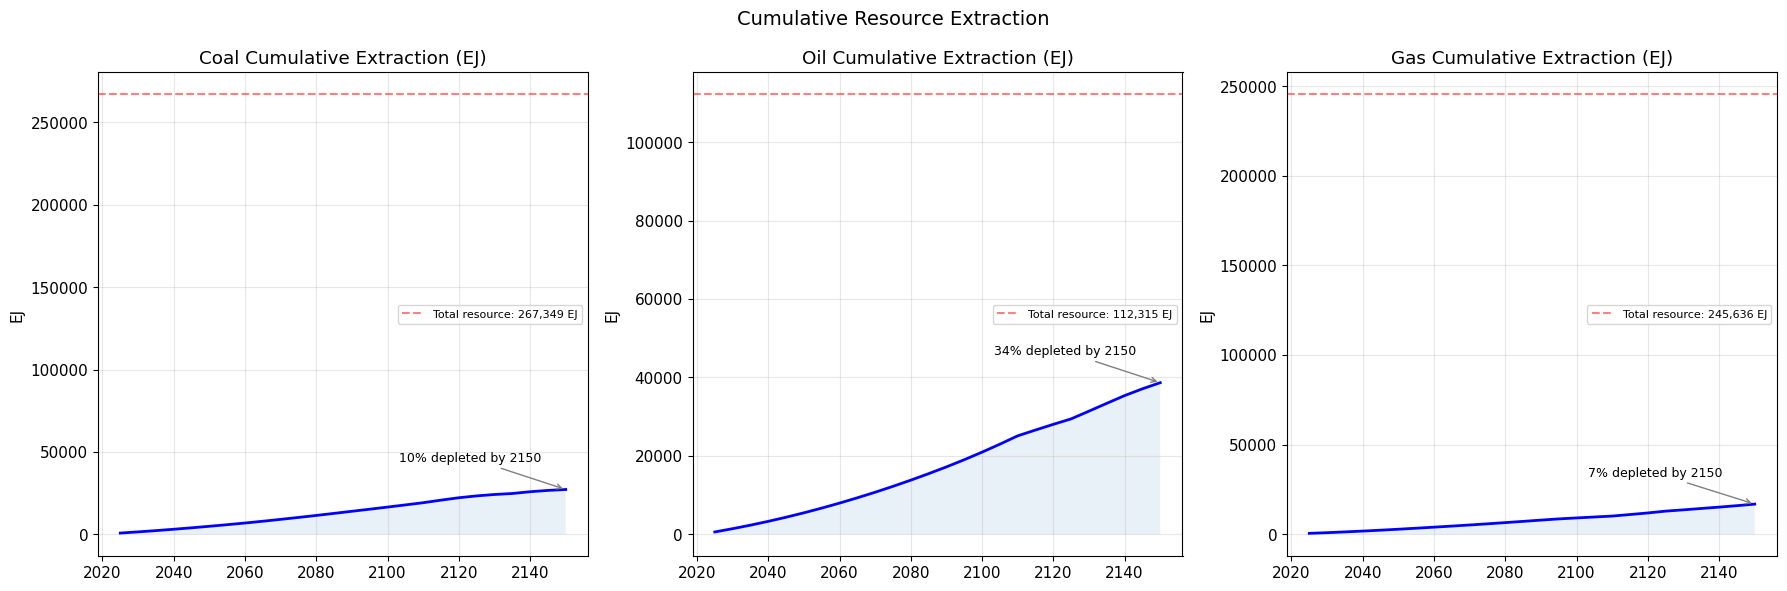

In [17]:
# Compute cumulative extraction over model run
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fuel in zip(axes, TRADED_FUELS):
    cum_prod = proj.groupby("year")[f"domestic_production_{fuel}_ej"].sum().cumsum() * TIMESTEP
    total_resource = r10_curves[r10_curves["fuel"] == fuel]["available"].sum()
    ax.plot(cum_prod.index, cum_prod.values, "b-", linewidth=2)
    ax.axhline(total_resource, color="red", ls="--", alpha=0.5,
              label=f"Total resource: {total_resource:,.0f} EJ")
    ax.fill_between(cum_prod.index, 0, cum_prod.values, alpha=0.1)
    ax.set_title(f"{fuel.title()} Cumulative Extraction (EJ)")
    ax.set_ylabel("EJ")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    # % depleted annotation
    pct = cum_prod.values[-1] / total_resource * 100
    ax.annotate(f"{pct:.0f}% depleted by {int(cum_prod.index[-1])}",
               xy=(cum_prod.index[-1], cum_prod.values[-1]), fontsize=9,
               xytext=(-120, 20), textcoords="offset points",
               arrowprops=dict(arrowstyle="->", color="gray"))

plt.suptitle("Cumulative Resource Extraction", fontsize=14)
plt.tight_layout()
plt.show()

---
## 10. Comparison: Trade vs No-Trade

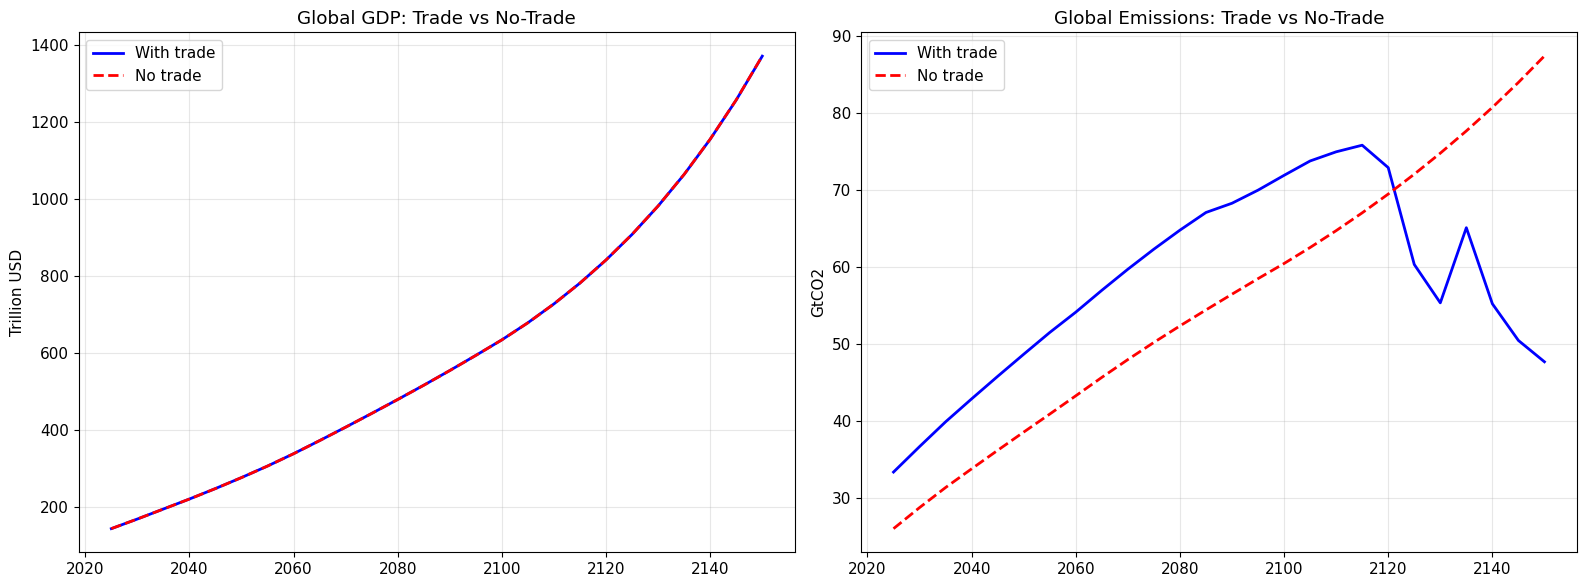

In [18]:
results_notrade = run_model(ssp_data, "SSP2", trade_enabled=False)
df_nt = results_to_dataframe(results_notrade)
proj_nt = df_nt[df_nt["year"] > BASE_YEAR].copy()

# GDP comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global GDP
ax = axes[0]
global_gdp_trade = proj.groupby("year")["gross_output_billion_usd"].sum() / 1e3
global_gdp_nt = proj_nt.groupby("year")["gross_output_billion_usd"].sum() / 1e3
ax.plot(global_gdp_trade.index, global_gdp_trade.values, "b-", linewidth=2, label="With trade")
ax.plot(global_gdp_nt.index, global_gdp_nt.values, "r--", linewidth=2, label="No trade")
ax.set_title("Global GDP: Trade vs No-Trade")
ax.set_ylabel("Trillion USD")
ax.grid(True, alpha=0.3)
ax.legend()

# Global emissions
ax = axes[1]
global_emis_trade = proj.groupby("year")["emissions_mtco2"].sum() / 1e3
global_emis_nt = proj_nt.groupby("year")["emissions_mtco2"].sum() / 1e3
ax.plot(global_emis_trade.index, global_emis_trade.values, "b-", linewidth=2, label="With trade")
ax.plot(global_emis_nt.index, global_emis_nt.values, "r--", linewidth=2, label="No trade")
ax.set_title("Global Emissions: Trade vs No-Trade")
ax.set_ylabel("GtCO2")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

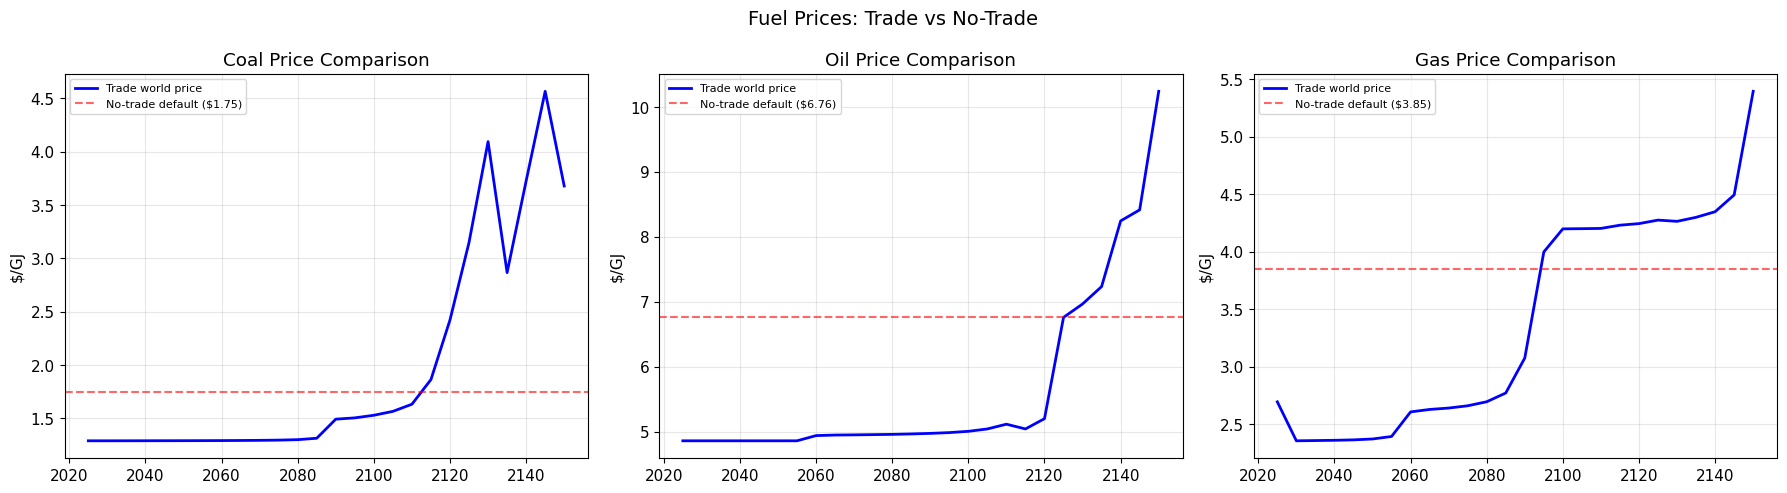

In [19]:
# Energy prices comparison (global average delivered)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, fuel in zip(axes, TRADED_FUELS):
    wp_trade = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")[f"world_price_{fuel}_usd_gj"]
    years = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")["year"]
    ax.plot(years, wp_trade, "b-", linewidth=2, label="Trade world price")

    # No-trade: fuel price is constant default
    ax.axhline(OBSERVED_FUEL_PRICES_2020[fuel], color="r", ls="--", alpha=0.6,
              label=f"No-trade default (${OBSERVED_FUEL_PRICES_2020[fuel]:.2f})")
    ax.set_title(f"{fuel.title()} Price Comparison")
    ax.set_ylabel("$/GJ")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Fuel Prices: Trade vs No-Trade", fontsize=14)
plt.tight_layout()
plt.show()

---
## 11. Diagnostic Summary

In [20]:
# Automated checks
checks = []

# Check 1: World prices positive and within bounds
for fuel in TRADED_FUELS:
    wps = proj[proj["region"] == R10_REGIONS[0]][f"world_price_{fuel}_usd_gj"]
    checks.append({
        "Check": f"{fuel} world price > 0",
        "Result": "PASS" if (wps > 0).all() else "FAIL",
        "Detail": f"Range: ${wps.min():.2f} - ${wps.max():.2f}",
    })
    checks.append({
        "Check": f"{fuel} price within ceiling",
        "Result": "PASS" if (wps <= TRADE_PRICE_CEILING * 1.5).all() else "FAIL",
        "Detail": f"Max: ${wps.max():.2f}, Ceiling: ${TRADE_PRICE_CEILING:.0f}",
    })

# Check 2: Global production = global demand (within tolerance)
for fuel in TRADED_FUELS:
    for year in [2050, 2100]:
        ydf = proj[proj["year"] == year]
        total_prod = ydf[f"domestic_production_{fuel}_ej"].sum()
        total_nx = ydf[f"net_exports_{fuel}_ej"].sum()
        checks.append({
            "Check": f"{fuel} market balance ({year})",
            "Result": "PASS" if abs(total_nx) < 1.0 else "FAIL",
            "Detail": f"Net exports sum: {total_nx:+.2f} EJ (should be ~0)",
        })

# Check 3: Price change rate within bounds (allow small tolerance)
for fuel in TRADED_FUELS:
    fdf = proj[proj["region"] == R10_REGIONS[0]].sort_values("year")
    p = fdf[f"world_price_{fuel}_usd_gj"].values
    max_rate = max(abs(np.diff(p) / p[:-1]))
    checks.append({
        "Check": f"{fuel} max price change rate",
        "Result": "PASS" if max_rate <= TRADE_MAX_PRICE_CHANGE + 0.02 else "FAIL",
        "Detail": f"Max: {max_rate*100:.1f}% (limit: {TRADE_MAX_PRICE_CHANGE*100:.0f}%)",
    })

# Check 4: No production cliff (30%+ decline)
for fuel in TRADED_FUELS:
    max_decline = 0
    worst_case = ""
    for region in R10_REGIONS:
        rdf = proj[proj["region"] == region].sort_values("year")
        prod = rdf[f"domestic_production_{fuel}_ej"].values
        for i in range(1, len(prod)):
            if prod[i-1] > 0.5:
                dec = (prod[i-1] - prod[i]) / prod[i-1]
                if dec > max_decline:
                    max_decline = dec
                    worst_case = f"{region} at {rdf['year'].values[i]}"
    checks.append({
        "Check": f"{fuel} max production decline",
        "Result": "PASS" if max_decline <= TRADE_MAX_PROD_DECLINE + 0.02 else "FAIL",
        "Detail": f"Max: {max_decline*100:.1f}% ({worst_case})",
    })

print("Trade Module Diagnostic Checks\n")
check_df = pd.DataFrame(checks)
print(check_df.to_string(index=False))
passes = (check_df["Result"] == "PASS").sum()
print(f"\n{passes}/{len(check_df)} checks passed")

Trade Module Diagnostic Checks

                      Check Result                                   Detail
       coal world price > 0   PASS                     Range: $1.29 - $4.57
  coal price within ceiling   PASS                 Max: $4.57, Ceiling: $50
        oil world price > 0   PASS                    Range: $4.86 - $10.24
   oil price within ceiling   PASS                Max: $10.24, Ceiling: $50
        gas world price > 0   PASS                     Range: $2.36 - $5.40
   gas price within ceiling   PASS                 Max: $5.40, Ceiling: $50
 coal market balance (2050)   PASS Net exports sum: -0.00 EJ (should be ~0)
 coal market balance (2100)   PASS Net exports sum: -0.00 EJ (should be ~0)
  oil market balance (2050)   PASS Net exports sum: +0.00 EJ (should be ~0)
  oil market balance (2100)   FAIL Net exports sum: -3.45 EJ (should be ~0)
  gas market balance (2050)   PASS Net exports sum: -0.15 EJ (should be ~0)
  gas market balance (2100)   PASS Net exports sum: -0.9

---
## 12. Summary Statistics

In [21]:
print("Trade Summary at Selected Years\n")
for fuel in TRADED_FUELS:
    print(f"=== {fuel.upper()} ===")
    summary_years = [2025, 2050, 2075, 2100, 2150]
    rows = []
    for year in summary_years:
        ydf = proj[proj["year"] == year]
        if ydf.empty:
            continue
        total_prod = ydf[f"domestic_production_{fuel}_ej"].sum()
        total_imports = -ydf[ydf[f"net_exports_{fuel}_ej"] < 0][f"net_exports_{fuel}_ej"].sum()
        total_exports = ydf[ydf[f"net_exports_{fuel}_ej"] > 0][f"net_exports_{fuel}_ej"].sum()
        wp = ydf[f"world_price_{fuel}_usd_gj"].iloc[0]
        rows.append({
            "Year": year,
            "World Price ($/GJ)": f"{wp:.2f}",
            "Global Prod (EJ)": f"{total_prod:.1f}",
            "Trade Volume (EJ)": f"{total_exports:.1f}",
            "Trade/Prod (%)": f"{total_exports/total_prod*100:.0f}" if total_prod > 0 else "N/A",
        })
    print(pd.DataFrame(rows).to_string(index=False))
    print()

Trade Summary at Selected Years

=== COAL ===
 Year World Price ($/GJ) Global Prod (EJ) Trade Volume (EJ) Trade/Prod (%)
 2025               1.29            145.4              33.6             23
 2050               1.29            185.3              66.1             36
 2075               1.30            235.0              58.7             25
 2100               1.53            257.6              77.6             30
 2150               3.68            111.1              50.6             46

=== OIL ===
 Year World Price ($/GJ) Global Prod (EJ) Trade Volume (EJ) Trade/Prod (%)
 2025               4.86            117.8              40.5             34
 2050               4.86            224.9              74.1             33
 2075               4.95            301.3              84.7             28
 2100               5.01            387.0             142.5             37
 2150              10.24            312.0              98.9             32

=== GAS ===
 Year World Price ($/GJ) Glo

---
---
# Model Documentation

## A. Data Source and Pipeline

### A.1 Source Data
The fossil fuel supply curves originate from **GCAM's PREBUILT_DATA.rda** file,
specifically `L111.RsrcCurves_EJ_R_Ffos`. This dataset contains grade-based
supply curves for 32 GCAM regions (R32), extracted using `scripts/export_fos_curves.R`.

The exported CSV (`ghim/data/external/energy/fos_curves_R32.csv`) has columns:
- `GCAM_region_ID` — integer 1-32 identifying GCAM region
- `resource` — "coal", "crude oil", or "natural gas"
- `subresource` — sub-category within each fuel (e.g., "coal (conv)", "coal (unconv)")
- `grade` — quality tier (e.g., "grade 1" through "grade 6")
- `available` — resource stock in that grade (EJ, cumulative)
- `extractioncost` — extraction cost in 1975 USD per GJ

### A.2 R32 -> Country Downscaling
Each R32 region contains multiple countries. Grade-level resource availability
is split to countries proportionally by GDP (PPP, 2020):

$$\text{available}_{country} = \text{available}_{R32} \times \frac{GDP_{country}}{GDP_{R32}}$$

GDP data comes from the SSP database (`SSP_database_2024.csv.gz`), using
"Historical Reference" when available, falling back to SSP2.

### A.3 Country -> R10 Aggregation
Countries are mapped to 10 AR6 R10 regions using `region_classification.tsv`
(direct ISO -> R10 mapping, NOT via GCAM R32). Available resource within each
(R10, fuel, cost-level) pair is summed across all constituent countries.

### A.4 Cost Deflation
GCAM stores extraction costs in **1975 USD**. GHIM converts to **2020 USD**
using the BEA GDP deflator:

$$\text{cost}_{2020} = \text{cost}_{1975} \times 3.79$$

where $3.79 = 105.381 / 27.800$ (BEA implicit price deflator for GDP, 2020 vs 1975).

## B. Supply Curve Interpolation

### B.1 Grade Structure
Each (region, fuel) pair has a `ResourceSupply` object containing a sorted list
of `ResourceGrade` objects (sorted by ascending extraction cost):

| Property | Type | Description |
|----------|------|-------------|
| `available` | float | Total EJ in this grade |
| `extraction_cost` | float | $/GJ to extract |

### B.2 Piecewise-Linear Interpolation
The function `production_at_price(price)` returns how much a region can produce
at a given world price. It uses **GCAM-style piecewise-linear** interpolation
(matching `cumulsupply()` in GCAM's `subresource.cpp:313-362`):

For each grade $i$ (sorted by cost):
1. If `price >= grade_cost[i]`: full remaining grade available
2. If `grade_cost[i-1] < price < grade_cost[i]`: linear ramp
   $$\text{fraction} = \frac{\text{price} - \text{cost}_{i-1}}{\text{cost}_i - \text{cost}_{i-1}}$$
   $$\text{production}_i = \text{remaining}_i \times \text{fraction}$$
3. If `price <= grade_cost[i-1]`: zero from this and all higher grades

**Special case**: For the first grade ($i=0$), the "previous cost" is 0,
so supply ramps from 0 at price=0 to full at `grade_cost[0]`.

**Depletion**: `cumulative_extracted` shifts the starting point. If extraction
exceeds a grade's `available`, that grade is partially or fully depleted, and
the effective remaining resource for price evaluation shrinks accordingly.

**Production cap**: `max_annual_production = base_year_production * 3.0` prevents
resource stocks (thousands of EJ) from being produced in a single period.

### B.3 Why Piecewise-Linear?
Step-function supply curves cause solver oscillation: at a grade boundary, an
infinitesimal price change triggers a discontinuous supply jump. The linear
interpolation makes supply a continuous function of price, ensuring bisection
converges to a unique equilibrium.

## C. Market Clearing Algorithm

### C.1 Bisection
For each traded fuel (coal, oil, gas), `GlobalMarket.clear_market()` finds the
world price where global supply equals global demand:

$$\sum_{r} S_r(p^* + \text{rent}) = \sum_{r} D_r$$

The algorithm:
1. Initialize `[lo, hi] = [0.1, 50.0]` ($/GJ)
2. Evaluate excess supply at midpoint: `excess = total_supply(mid + rent) - total_demand`
3. If `|excess| < 0.01 * total_demand`: converged
4. If `excess > 0` (oversupply): `hi = mid`; else `lo = mid`
5. Repeat up to 50 iterations
6. Return `world_price = mid + rent`

### C.2 Scarcity Handling
If maximum supply capacity at `price_hi + rent` is less than total demand,
a **scarcity premium** is applied:

$$p_\text{clearing} = \min\left(p_\text{highest\_grade} \times \frac{D}{S_\text{max}},\; p_\text{ceiling}\right)$$

### C.3 Calibration Rent
At the first projection period (2025), a one-time calibration computes:
$$\text{rent}_f = \max(0,\; p_\text{observed} - p_\text{cleared})$$

This rent (representing scarcity rents, market power, royalties) is added to
bisection evaluations in all subsequent periods, so `world_price` reflects both
extraction cost and rent.

| Fuel | Observed ($/GJ) | Extraction clearing | Rent |
|------|----------------|-------------------|------|
| Coal | 1.75 | varies | varies |
| Oil  | 6.76 | varies | varies |
| Gas  | 3.85 | varies | varies |

## D. Demand-Trade Iteration

### D.1 Why Iterate?
Energy demand depends on fuel prices (through the KLEM energy demand function
and fuel-switching logit). But trade-cleared prices depend on demand. This
circular dependency requires iteration.

### D.2 Algorithm
```
for iter = 1 to 10:
    1. Estimate demand per region using current prices
       (compute_primary_fuel_demand)
    2. Clear global markets -> new world prices
    3. Compute delivered prices -> new price signals
    4. Check convergence (2% relative price change)
    5. Damped price update (50% new + 50% old)
```

If not converged after 10 iterations, **average the last two demand estimates**
and do a final clearing. This produces a smooth result between oscillating states.

### D.3 Warm-Starting
The demand-trade loop warm-starts from the previous period's cleared prices.
This means iteration begins near the converged solution rather than from
default fuel prices, typically converging in 2-3 iterations.

## E. Inter-Period Smoothing

### E.1 Price Smoothing
After market clearing, world prices are clamped to change at most
**30%** per period relative to the previous period:

$$p_t = \text{clamp}(p_\text{cleared},\; p_{t-1} \times 0.7,\; p_{t-1} \times 1.3)$$

This prevents grade-boundary jumps where depletion of one grade causes a
sudden price jump to the next grade's cost.

### E.2 Production Smoothing
Per-region production declines are limited to **30%** per period
(allowing halving in ~10 years: $0.7^2 = 0.49$):

$$Q_{r,t} \geq Q_{r,t-1} \times (1 - 0.30)$$

The algorithm is **iterative**: after flooring constrained regions,
unconstrained regions are scaled down to preserve total production.
If this scaling causes new regions to violate the limit, the process
repeats until stable. Growth is not constrained.

### E.3 Resource Depletion
After smoothing, cumulative extraction is updated:

$$\text{cumulative}_{r,f} += Q_{r,f,t} \times dt$$

This uses the **smoothed** production values, so depletion reflects
the actual (inertia-limited) extraction, not the unconstrained equilibrium.

## F. Transport Costs

Delivered price = world price + transport cost.
Transport costs are fuel- and region-specific:

| Fuel | Base Cost | Notes |
|------|-----------|-------|
| Coal | $0.50/GJ | Bulk shipping |
| Oil  | $0.30/GJ | Tanker |
| Gas  | $0.80/GJ | LNG/pipeline |

Regional multipliers adjust for geography:
- Middle East oil: 0.4x (major producer, minimal transport)
- Eastern Asia gas: 1.5x (LNG import-dependent)
- Eurasia gas: 0.5x (pipeline infrastructure)
- Africa coal: 1.2x (limited port infrastructure)

## G. Parameters Reference

| Parameter | Value | Description |
|-----------|-------|-------------|
| `TRADED_FUELS` | coal, oil, gas | Fuels cleared via global market |
| `TRADE_PRICE_TOL` | 0.01 $/GJ | Bisection convergence tolerance |
| `TRADE_MAX_ITER` | 50 | Max bisection iterations |
| `TRADE_PRICE_FLOOR` | 0.10 $/GJ | Min world price |
| `TRADE_PRICE_CEILING` | 50.0 $/GJ | Max world price |
| `TRADE_DEMAND_MAX_ITER` | 10 | Max demand-trade iterations |
| `TRADE_DEMAND_DAMP` | 0.50 | Damping for demand loop |
| `TRADE_DEMAND_TOL` | 0.02 | 2% price convergence |
| `TRADE_MAX_PRICE_CHANGE` | 0.30 | 30% max inter-period price change |
| `TRADE_MAX_PROD_DECLINE` | 0.30 | 30% max production decline per region |
| `GCAM3_TO_2020_DEFLATOR` | 3.79 | 1975$ -> 2020$ conversion |
| `production_cap_factor` | 3.0 | Max annual prod = 3x base year |
| `TIMESTEP` | 5 years | Model period length |